
        # Previsão de Volumetria — Transportadora

        História: vamos transformar o histórico da produção em decisões melhores. Exploramos o passado (EDA), enriquecemos com calendário comercial (exógenos), criamos bons atributos (lags e janelas móveis) e avaliamos três modelos complementares: SARIMAX (séries + exógenos), Holt-Winters com ajuste exógeno (sazonalidade + efeito calendário) e LightGBM (aprendizado de máquina com lags). Validamos de forma temporal, iterando hiperparâmetros e medindo MAPE e RMSE. Por fim, combinamos os modelos com um ensemble ponderado por MAPE por dia da semana × evento exógeno e entregamos a previsão dos próximos 30 dias em Excel.

        ## Plano de Trabalho
        - Instalação e importação de bibliotecas
        - Carregamento dos dados (Histórico e Calendário)
        - Engenharia de atributos: lags, rollings e junção dos exógenos
        - Análise exploratória (tendências, sazonalidades por dia/mês)
        - Modelagem: SARIMAX, Holt-Winters (com ajuste exógeno) e LightGBM
        - Busca de hiperparâmetros (até 6 por modelo por dobra)
        - Validação cruzada temporal (01/01/2024 → 01/06/2025, passo 30, horizonte 30)
        - Registro de métricas e previsões por dia em Excel
        - Ensemble ponderado por MAPE (dia da semana × exógeno)
        - Previsão dos próximos 30 dias em Excel
        

## 1. Instalação de Bibliotecas

In [1]:

        # Se necessário, descomente para instalação
        # !pip install -q pandas numpy matplotlib seaborn scikit-learn statsmodels lightgbm openpyxl xlrd
        

## 2. Importação das Bibliotecas

In [2]:

        import os
        import sys
        import math
        import warnings
        warnings.filterwarnings('ignore')

        import numpy as np
        import pandas as pd
        import matplotlib.pyplot as plt
        import seaborn as sns

        from datetime import datetime, timedelta
        from dateutil.relativedelta import relativedelta

        from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
        from sklearn.model_selection import ParameterGrid
        from sklearn.linear_model import Ridge

        import lightgbm as lgb
        from statsmodels.tsa.statespace.sarimax import SARIMAX
        from statsmodels.tsa.holtwinters import ExponentialSmoothing

        pd.set_option('display.max_columns', 200)
        sns.set(style='whitegrid')
        

## 3. Carregamento dos DataFrames

In [3]:
# Caminhos (ajuste caso necessário)
HIST_PATH = r"C:\\Users\\rafael.franca\\OneDrive - JADLOG LOGISTICA LTDA\\Meu Computador\\GitHubCopilot\\Historico.csv"
CAL_PATH  = r"C:\\Users\\rafael.franca\\OneDrive - JADLOG LOGISTICA LTDA\\Meu Computador\\GitHubCopilot\\calendario.csv"

EXOG_RAW = [
    'Domingo','Sabado','Segunda_Feira','feriado_nacional','volta_as_aulas',
    'dia_das_maes','dia_dos_namorados','dia_dos_pais','semana_black_friday',
    'ressaca_black_friday','periodo_natal_pre','liquidacao_janeiro'
]

def _clean_cols(cols):
    return [c.strip().lower().replace(' ', '_').replace('ã','a').replace('á','a').replace('é','e').replace('í','i').replace('ó','o').replace('ú','u').replace('ç','c') for c in cols]

def read_csv_robust(path):
    for enc in ['utf-8-sig','latin1','cp1252']:
        try:
            return pd.read_csv(path, encoding=enc, sep=None, engine='python')
        except Exception:
            pass
    return pd.read_csv(path)

hist = read_csv_robust(HIST_PATH)
cal  = read_csv_robust(CAL_PATH)

hist.columns = _clean_cols(hist.columns)
cal.columns  = _clean_cols(cal.columns)

# Detectar coluna de data
date_cols_hist = [c for c in hist.columns if c in ['data','date','dt'] or 'data' in c or 'date' in c]
if not date_cols_hist:
    date_col_hist = hist.columns[0]
else:
    date_col_hist = date_cols_hist[0]

date_cols_cal = [c for c in cal.columns if c in ['data','date','dt'] or 'data' in c or 'date' in c]
if not date_cols_cal:
    date_col_cal = cal.columns[0]
else:
    date_col_cal = date_cols_cal[0]

# Ajuste para datas em formato brasileiro (dd/mm/aaaa) com fallback
hist[date_col_hist] = pd.to_datetime(hist[date_col_hist], dayfirst=True, errors='coerce')
cal[date_col_cal]   = pd.to_datetime(cal[date_col_cal], dayfirst=True, errors='coerce')

# Coluna-alvo (volumetria): primeira numérica que não é data/exógena
exog_clean = _clean_cols(EXOG_RAW)
cand = [c for c in hist.columns if c not in [date_col_hist] and c not in exog_clean]
num_cand = [c for c in cand if pd.api.types.is_numeric_dtype(hist[c])]
if not num_cand:
    raise ValueError('Não foi encontrada coluna numérica de volumetria no Historico.csv')
# Se houver mais de uma linha por data, agregue (soma para volumetria)
target_col = num_cand[0]
hist = hist.groupby(date_col_hist, as_index=False)[target_col].sum()
# Para o calendário, agregue por data usando max para variáveis binárias
cal = cal.groupby(date_col_cal, as_index=False).max(numeric_only=True)

hist = hist[[date_col_hist, target_col]].rename(columns={date_col_hist:'data', target_col:'y'})
cal  = cal.rename(columns={date_col_cal:'data'})

# Garantir exógenas binárias
for c in exog_clean:
    if c not in cal.columns:
        cal[c] = 0
    cal[c] = cal[c].fillna(0).astype(int)

# Merge
df = pd.merge(hist, cal[['data'] + exog_clean], on='data', how='left').sort_values('data')
for c in exog_clean:
    df[c] = df[c].fillna(0).astype(int)

# Garantir unicidade de datas após o merge
df = df.drop_duplicates(subset=['data'])

df['data'] = pd.to_datetime(df['data'])
df = df.set_index('data').asfreq('D')
df['y'] = pd.to_numeric(df['y'], errors='coerce')
df['y'] = df['y'].interpolate(limit_direction='both')

print('Histórico:', hist.shape, '| Calendário:', cal.shape)
display(df.head())


Histórico: (670, 2) | Calendário: (1096, 13)


,y,domingo,sabado,segunda_feira,feriado_nacional,volta_as_aulas,dia_das_maes,dia_dos_namorados,dia_dos_pais,semana_black_friday,ressaca_black_friday,periodo_natal_pre,liquidacao_janeiro
data,,,,,,,,,,,,,
2024-01-01,8.000,0,0,1,1,0,0,0,0,0,0,0,0
2024-01-02,61.103,0,0,0,0,1,0,0,0,0,0,0,0
2024-01-03,93.236,0,0,0,0,1,0,0,0,0,0,0,0
2024-01-04,129.560,0,0,0,0,1,0,0,0,0,0,0,0
2024-01-05,123.660,0,0,0,0,1,0,0,0,0,0,0,0


## 4. Engenharia de Features (lags, rollings e exógenas)

In [4]:

        LAGS = [1,7,14,28]
        ROLL_WINDOWS = [7,14,28]

        exog_cols = [c for c in df.columns if c != 'y']

        # Data parts
        df['dow'] = df.index.dayofweek
        df['month'] = df.index.month

        # Lags
        for l in LAGS:
            df[f'lag_{l}'] = df['y'].shift(l)

        # Rollings
        for w in ROLL_WINDOWS:
            df[f'roll_mean_{w}'] = df['y'].shift(1).rolling(w).mean()
            df[f'roll_std_{w}']  = df['y'].shift(1).rolling(w).std()

        # Assinatura exógena (quais eventos ativos no dia)
        EXOG_COLS = [c for c in df.columns if c not in ['y','dow','month'] and not c.startswith('lag_') and not c.startswith('roll_')]
        def signature(row):
            actives = [c for c in EXOG_COLS if row.get(c,0)==1]
            return 'none' if len(actives)==0 else '+'.join(sorted(actives))
        df['exog_signature'] = df.apply(signature, axis=1)

        display(df.tail(3))
        

,y,domingo,sabado,segunda_feira,feriado_nacional,volta_as_aulas,dia_das_maes,dia_dos_namorados,dia_dos_pais,semana_black_friday,ressaca_black_friday,periodo_natal_pre,liquidacao_janeiro,dow,month,lag_1,lag_7,lag_14,lag_28,roll_mean_7,roll_std_7,roll_mean_14,roll_std_14,roll_mean_28,roll_std_28,exog_signature
data,,,,,,,,,,,,,,,,,,,,,,,,,,
2025-10-29,186.547,0,0,0,0,0,0,0,0,0,0,0,0,2,10,169.639,192.776,226.904,181.642,142.041429,55.775505,149.044214,61.186002,144.046500,58.101432,none
2025-10-30,169.074,0,0,0,0,0,0,0,0,0,0,0,0,3,10,186.547,175.149,211.811,170.411,141.151571,54.873563,146.161571,58.108934,144.221679,58.226242,none
2025-10-31,168.241,0,0,0,0,0,0,0,0,0,0,0,0,4,10,169.074,183.296,199.162,164.551,140.283714,54.291209,143.108929,55.456912,144.173929,58.204514,none


## 5. Análise Exploratória

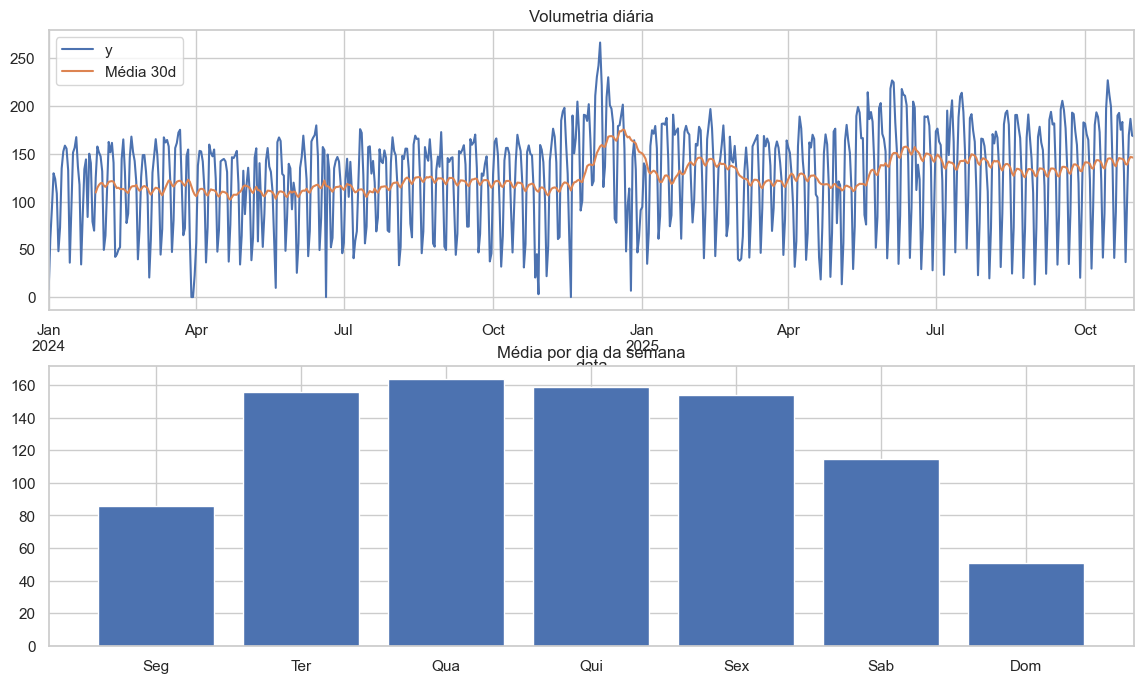

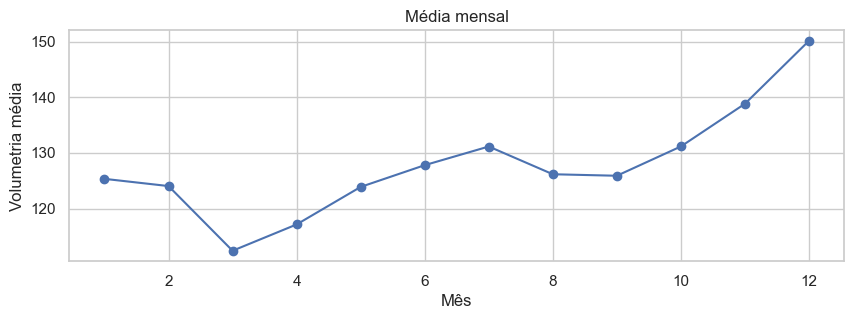

In [5]:
fig, ax = plt.subplots(2,1, figsize=(14,8))
df['y'].plot(ax=ax[0], title='Volumetria diária')
df['y'].rolling(30).mean().plot(ax=ax[0], label='Média 30d')
ax[0].legend()

weekly = df['y'].groupby(df.index.dayofweek).mean()
ax[1].bar(range(7), weekly.values)
ax[1].set_xticks(range(7))
ax[1].set_xticklabels(['Seg','Ter','Qua','Qui','Sex','Sab','Dom'])
ax[1].set_title('Média por dia da semana')
plt.show()

monthly = df['y'].groupby(df.index.month).mean()
plt.figure(figsize=(10,3))
plt.plot(range(1,13), monthly.values, marker='o')
plt.title('Média mensal'); plt.xlabel('Mês'); plt.ylabel('Volumetria média')
plt.show()


## 6. Modelos e Busca de Hiperparâmetros

In [6]:

        def mape(y_true, y_pred):
            return float(mean_absolute_percentage_error(y_true, y_pred) * 100)

        def rmse(y_true, y_pred):
            return float(math.sqrt(mean_squared_error(y_true, y_pred)))

        def make_train_test(df, train_start, train_end, horizon=30):
            train = df.loc[train_start:train_end].copy()
            test_start = pd.to_datetime(train_end) + pd.Timedelta(days=1)
            test_end = test_start + pd.Timedelta(days=horizon-1)
            test = df.loc[test_start:test_end].copy()
            return train, test

        # SARIMAX
        def sarimax_forecast(train, test, exog_cols, order=(1,1,1), seasonal_order=(0,1,1,7)):
            mod = SARIMAX(train['y'], order=order, seasonal_order=seasonal_order, exog=train[exog_cols], enforce_stationarity=False, enforce_invertibility=False)
            res = mod.fit(disp=False)
            pred = res.predict(start=test.index[0], end=test.index[-1], exog=test[exog_cols])
            return pred, res

        # Holt-Winters + ajuste exógeno (Ridge nos resíduos)
        def holt_exog_forecast(train, test, exog_cols, trend='add', seasonal='add', seasonal_periods=7, ridge_alpha=1.0):
            ets = ExponentialSmoothing(train['y'], trend=trend, seasonal=seasonal, seasonal_periods=seasonal_periods)
            ets_fit = ets.fit(optimized=True)
            base_pred = ets_fit.predict(start=test.index[0], end=test.index[-1])

            # Ajuste exógeno nos resíduos
            resid = train['y'] - ets_fit.fittedvalues
            Xr = train[exog_cols].copy()
            rr = Ridge(alpha=ridge_alpha)
            rr.fit(Xr, resid)
            adj = rr.predict(test[exog_cols])
            pred = base_pred + adj
            return pred, (ets_fit, rr)

        # LightGBM com lags/rollings
        LGB_FEATURES = [c for c in df.columns if c != 'y' and (c.startswith('lag_') or c.startswith('roll_') or c in ['dow','month'] or c in [col for col in df.columns if col not in ['y','exog_signature'] and col not in [cc for cc in df.columns if cc.startswith('lag_') or cc.startswith('roll_')] and col not in ['dow','month'] and c!='exog_signature'])]
        # Remove exog_signature de features (é categórica textual)
        if 'exog_signature' in LGB_FEATURES:
            LGB_FEATURES.remove('exog_signature')

        def lgbm_train_predict(train, test, params=None, n_estimators=500, early_stopping_rounds=50):
            params = params or {
                'learning_rate': 0.05,
                'num_leaves': 31,
                'feature_fraction': 0.9,
                'bagging_fraction': 0.8,
                'bagging_freq': 1,
                'min_child_samples': 20,
                'random_state': 42,
                'objective': 'regression'
            }

            tr = train.dropna().copy()
            X_tr = tr[LGB_FEATURES]
            y_tr = tr['y']

            if len(tr) < 20:
                # Poucos dados: treina em tudo sem val
                model = lgb.LGBMRegressor(n_estimators=n_estimators, **params)
                model.fit(X_tr, y_tr)
            else:
                # Validação interna simples: última parte do treino como validação
                val_cut = int(len(tr) * 0.8)
                X_tr_i, y_tr_i = X_tr.iloc[:val_cut], y_tr.iloc[:val_cut]
                X_val_i, y_val_i = X_tr.iloc[val_cut:], y_tr.iloc[val_cut:]

                model = lgb.LGBMRegressor(n_estimators=n_estimators, **params)
                model.fit(X_tr_i, y_tr_i, eval_set=[(X_val_i, y_val_i)])

            # Previsão no horizonte: precisamos das features já calculadas em 'test'
            X_te = test[LGB_FEATURES].copy()
            pred = pd.Series(model.predict(X_te), index=test.index)
            return pred, model

        # Busca de hiperparâmetros (máx. 6 por modelo)
        SARIMAX_GRID = [
            {'order': (2,1,1), 'seasonal_order': (0,1,1,7), 'enforce_stationarity': False, 'enforce_invertibility': False},
            {'order': (1,1,0), 'seasonal_order': (0,1,1,7), 'enforce_stationarity': False, 'enforce_invertibility': False},
            {'order': (1,1,1), 'seasonal_order': (0,1,1,14), 'enforce_stationarity': False, 'enforce_invertibility': False},
            {'order': (1,0,1), 'seasonal_order': (1,1,1,14), 'enforce_stationarity': False, 'enforce_invertibility': False},
            {'order': (1,1,2), 'seasonal_order': (0,1,1,30), 'enforce_stationarity': False, 'enforce_invertibility': False},
            {'order': (2,1,1), 'seasonal_order': (1,1,0,30), 'enforce_stationarity': False, 'enforce_invertibility': False}
        ]

        HOLT_GRID = [
            {'trend':'add','seasonal':'add','seasonal_periods':7,'ridge_alpha':0.1},
            {'trend':'add','seasonal':'mul','seasonal_periods':7,'ridge_alpha':0.1},
            {'trend':'add','seasonal':'add','seasonal_periods':30,'ridge_alpha':0.1},
            {'trend':'mul','seasonal':'add','seasonal_periods':7,'ridge_alpha':1.0},
            {'trend':'add','seasonal':'add','seasonal_periods':14,'ridge_alpha':0.5},
            {'trend':'add','seasonal':'mul','seasonal_periods':14,'ridge_alpha':1.0}
        ]

        LGB_GRID = [
            {'learning_rate':0.05,'num_leaves':31,'min_child_samples':20,'feature_fraction':0.9,'bagging_fraction':0.8,'bagging_freq':1,'random_state':42},
            {'learning_rate':0.03,'num_leaves':63,'min_child_samples':15,'feature_fraction':0.9,'bagging_fraction':0.8,'bagging_freq':1,'random_state':42},
            {'learning_rate':0.1,'num_leaves':31,'min_child_samples':30,'feature_fraction':0.8,'bagging_fraction':0.8,'bagging_freq':1,'random_state':42},
            {'learning_rate':0.05,'num_leaves':15,'min_child_samples':10,'feature_fraction':0.8,'bagging_fraction':0.7,'bagging_freq':1,'random_state':42},
            {'learning_rate':0.05,'num_leaves':31,'min_child_samples':20,'feature_fraction':0.7,'bagging_fraction':0.7,'bagging_freq':1,'random_state':42},
            {'learning_rate':0.03,'num_leaves':127,'min_child_samples':20,'feature_fraction':0.9,'bagging_fraction':0.8,'bagging_freq':1,'random_state':42}
        ]

## 7. Validação Cruzada Temporal (30d passo, 30d horizonte)

In [ ]:
# Parâmetros da validação
TRAIN_START = pd.Timestamp('2024-01-01')
LAST_TRAIN_END = pd.Timestamp('2025-10-31')
STEP_DAYS = 30
HORIZON = 30

exog_model_cols = [c for c in df.columns if c not in ['y'] and not c.startswith('lag_') and not c.startswith('roll_') and c not in ['dow','month','exog_signature']]

# Resultados acumulados
rows = []

# Datas das dobras
cut = TRAIN_START
folds = []
while cut <= LAST_TRAIN_END:
    folds.append(cut)
    cut += pd.Timedelta(days=STEP_DAYS)

print(f"Total de dobras: {len(folds)}")

best_params = {'sarimax': None, 'holt': None, 'lgb': None}

for i, train_end in enumerate(folds):
    if i == 0:  # precisa haver ao menos 1 mês antes
        continue
    print(f"===== Dobra {i}/{len(folds)-1} | Treino até {train_end.date()} =====")
    train, test = make_train_test(df, TRAIN_START, train_end, horizon=HORIZON)
    if len(test)==0:
        print('Sem janela de teste disponível. Pulando.')
        continue

    # SARIMAX search
    best_mape_sar, best_sar, best_sar_pred = np.inf, None, None
    for j, p in enumerate(SARIMAX_GRID[:6], start=1):
        print(f"  SARIMAX {j}/6 -> {p}")
        try:
            pred_sar, model_sar = sarimax_forecast(train, test, exog_model_cols, order=p['order'], seasonal_order=p['seasonal_order'])
            cur = mape(test['y'], pred_sar)
            if cur < best_mape_sar:
                best_mape_sar, best_sar, best_sar_pred = cur, p, pred_sar
        except Exception as e:
            print('   falhou:', e)
    if best_params['sarimax'] is None and best_sar is not None:
        best_params['sarimax'] = best_sar

    # Holt-Winters + exógeno search
    best_mape_hw, best_hw, best_hw_pred = np.inf, None, None
    for j, p in enumerate(HOLT_GRID[:6], start=1):
        print(f"  Holt-Winters {j}/6 -> {p}")
        try:
            pred_hw, model_hw = holt_exog_forecast(train, test, exog_model_cols, **p)
            cur = mape(test['y'], pred_hw)
            if cur < best_mape_hw:
                best_mape_hw, best_hw, best_hw_pred = cur, p, pred_hw
        except Exception as e:
            print('   falhou:', e)
    if best_params['holt'] is None and best_hw is not None:
        best_params['holt'] = best_hw

    # LightGBM search
    best_mape_lgb, best_lgb, best_lgb_pred = np.inf, None, None
    for j, p in enumerate(LGB_GRID[:6], start=1):
        print(f"  LightGBM {j}/6 -> {p}")
        try:
            pred_lgb, model_lgb = lgbm_train_predict(train, test, params=p)
            cur = mape(test['y'], pred_lgb)
            if cur < best_mape_lgb:
                best_mape_lgb, best_lgb, best_lgb_pred = cur, p, pred_lgb
        except Exception as e:
            print('   falhou:', e)
    if best_params['lgb'] is None and best_lgb is not None:
        best_params['lgb'] = best_lgb

    # Salvar linhas por dia
    for dt_i in test.index:
        rows.append({
            'Data Inicial do Treino': TRAIN_START.date(),
            'Data Final do Treino': train_end.date(),
            'Data da Previsao': dt_i.date(),
            'Previsao_Sarimax': float(best_sar_pred.loc[dt_i]) if best_sar_pred is not None and dt_i in best_sar_pred.index else np.nan,
            'Previsao_Holt_Winters': float(best_hw_pred.loc[dt_i]) if best_hw_pred is not None and dt_i in best_hw_pred.index else np.nan,
            'Previsao_LightGB': float(best_lgb_pred.loc[dt_i]) if best_lgb_pred is not None and dt_i in best_lgb_pred.index else np.nan,
            'Producao_Realizada': float(test.loc[dt_i,'y']),
            'Diferenca_Sarimax_Real': float((best_sar_pred.loc[dt_i] - test.loc[dt_i,'y'])) if best_sar_pred is not None and dt_i in best_sar_pred.index else np.nan,
            'Diferenca_Holt_Winters_Real': float((best_hw_pred.loc[dt_i] - test.loc[dt_i,'y'])) if best_hw_pred is not None and dt_i in best_hw_pred.index else np.nan,
            'Diferenca_LightGB_Real': float((best_lgb_pred.loc[dt_i] - test.loc[dt_i,'y'])) if best_lgb_pred is not None and dt_i in best_lgb_pred.index else np.nan,
            'dow': int(test.loc[dt_i,'dow']) if 'dow' in test.columns else np.nan,
            'exog_signature': str(test.loc[dt_i,'exog_signature']) if 'exog_signature' in test.columns else 'none'
        })

cv_results = pd.DataFrame(rows)
print(f"Linhas geradas na validação: {len(cv_results)}")
out_val = 'resultados_validacao.xlsx'
with pd.ExcelWriter(out_val, engine='openpyxl') as writer:
    cv_results.to_excel(writer, index=False)
print('Arquivo salvo:', out_val)
display(cv_results.head())

best_params

Total de dobras: 23
===== Dobra 1/22 | Treino até 2024-01-31 =====
  SARIMAX 1/6 -> {'order': (2, 1, 1), 'seasonal_order': (0, 1, 1, 7), 'enforce_stationarity': False, 'enforce_invertibility': False}
  SARIMAX 2/6 -> {'order': (1, 1, 0), 'seasonal_order': (0, 1, 1, 7), 'enforce_stationarity': False, 'enforce_invertibility': False}


c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  SARIMAX 3/6 -> {'order': (1, 1, 1), 'seasonal_order': (0, 1, 1, 14), 'enforce_stationarity': False, 'enforce_invertibility': False}
  SARIMAX 4/6 -> {'order': (1, 0, 1), 'seasonal_order': (1, 1, 1, 14), 'enforce_stationarity': False, 'enforce_invertibility': False}
  SARIMAX 5/6 -> {'order': (1, 1, 2), 'seasonal_order': (0, 1, 1, 30), 'enforce_stationarity': False, 'enforce_invertibility': False}
  SARIMAX 6/6 -> {'order': (2, 1, 1), 'seasonal_order': (1, 1, 0, 30), 'enforce_stationarity': False, 'enforce_invertibility': False}
  Holt-Winters 1/6 -> {'trend': 'add', 'seasonal': 'add', 'seasonal_periods': 7, 'ridge_alpha': 0.1}
  Holt-Winters 2/6 -> {'trend': 'add', 'seasonal': 'mul', 'seasonal_periods': 7, 'ridge_alpha': 0.1}
  Holt-Winters 3/6 -> {'trend': 'add', 'seasonal': 'add', 'seasonal_periods': 30, 'ridge_alpha': 0.1}
   falhou: Cannot compute initial seasonals using heuristic method with less than two full seasonal cycles in the data.
  Holt-Winters 4/6 -> {'trend': 'mul', '

  File "c:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 199, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\ProgramData\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\ProgramData\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\ProgramData\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more 

...

  SARIMAX 3/6 -> {'order': (1, 1, 1), 'seasonal_order': (0, 1, 1, 14), 'enforce_stationarity': False, 'enforce_invertibility': False}


c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  SARIMAX 4/6 -> {'order': (1, 0, 1), 'seasonal_order': (1, 1, 1, 14), 'enforce_stationarity': False, 'enforce_invertibility': False}


c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  SARIMAX 5/6 -> {'order': (1, 1, 2), 'seasonal_order': (0, 1, 1, 30), 'enforce_stationarity': False, 'enforce_invertibility': False}


## 8. Ensemble ponderado por MAPE (Dia da Semana × Exógeno)

In [ ]:
# 8. Ensemble ponderado por MAPE (Dia da Semana × Exógeno) - versão limpa com fallback
import numpy as np
import pandas as pd

# Fallback: carregar resultados de validação do disco, se necessário
if 'cv_results' not in globals():
    try:
        cv_results = pd.read_excel('resultados_validacao.xlsx')
        print('cv_results carregado de resultados_validacao.xlsx')
    except Exception as e:
        raise RuntimeError('cv_results não encontrado no kernel e o arquivo resultados_validacao.xlsx não pôde ser lido.')

# Remover funções antigas se existirem
for _sym in ['compute_group_mape', 'ensemble_row']:
    if _sym in globals():
        del globals()[_sym]

# Construir group_mape inline
_frames = []
for _model in ['Previsao_Sarimax','Previsao_Holt_Winters','Previsao_LightGB']:
    sub = cv_results.dropna(subset=['Producao_Realizada', _model])
    if sub.empty:
        continue
    ser = sub.groupby(['dow','exog_signature']).apply(lambda x: mape(x['Producao_Realizada'], x[_model]))
    df_m = ser.to_frame('MAPE').reset_index()
    df_m['model'] = _model
    _frames.append(df_m)

if _frames:
    group_mape = pd.concat(_frames, ignore_index=True)
else:
    group_mape = pd.DataFrame(columns=['dow','exog_signature','MAPE','model'])

print('Linhas group_mape:', len(group_mape))
display(group_mape.head())

# Aplicar ensemble nos resultados de validação
EPS = 1e-6

def _ensemble_val(r):
    g = group_mape[(group_mape['dow']==r['dow']) & (group_mape['exog_signature']==r['exog_signature'])]
    if g.empty:
        g = group_mape.groupby('model', as_index=False)['MAPE'].mean()
    g = g.copy()
    g['w'] = 1.0/(g['MAPE']+EPS)
    sw = g['w'].sum()
    g['w'] = g['w']/sw if sw>0 else 1.0/len(g)
    preds = {
        'Previsao_Sarimax': r.get('Previsao_Sarimax', np.nan) if isinstance(r, dict) else r.get('Previsao_Sarimax', np.nan),
        'Previsao_Holt_Winters': r.get('Previsao_Holt_Winters', np.nan) if isinstance(r, dict) else r.get('Previsao_Holt_Winters', np.nan),
        'Previsao_LightGB': r.get('Previsao_LightGB', np.nan) if isinstance(r, dict) else r.get('Previsao_LightGB', np.nan)
    }
    return float(sum(preds.get(row['model'], np.nan) * row['w'] for _, row in g.iterrows()))

cv_results['Previsao_Ensemble'] = cv_results.apply(_ensemble_val, axis=1)

# Salvar arquivo de validação com ensemble
out_val2 = 'resultados_validacao_com_ensemble.xlsx'
with pd.ExcelWriter(out_val2, engine='openpyxl') as w:
    cv_results.to_excel(w, index=False)
    group_mape.to_excel(w, sheet_name='mape_grupos', index=False)
print('Arquivo salvo:', out_val2)
display(cv_results.head())


Linhas group_mape: 135


,dow,exog_signature,MAPE,model
0,0,feriado_nacional+segunda_feira,2.254005e+02,Previsao_Sarimax
1,0,liquidacao_janeiro+segunda_feira,1.726015e+01,Previsao_Sarimax
2,0,periodo_natal_pre+segunda_feira,2.807806e+01,Previsao_Sarimax
3,0,ressaca_black_friday+segunda_feira,3.102811e+01,Previsao_Sarimax
4,0,segunda_feira,3.795672e+17,Previsao_Sarimax


Arquivo salvo: resultados_validacao_com_ensemble.xlsx


,Data Inicial do Treino,Data Final do Treino,Data da Previsao,Previsao_Sarimax,Previsao_Holt_Winters,Previsao_LightGB,Producao_Realizada,Diferenca_Sarimax_Real,Diferenca_Holt_Winters_Real,Diferenca_LightGB_Real,dow,exog_signature,Previsao_Ensemble
0,2024-01-01,2024-01-31,2024-02-01,138.672670,148.350890,117.320666,151.411,-12.738330,-3.060110,-34.090334,3,volta_as_aulas,135.138110
1,2024-01-01,2024-01-31,2024-02-02,138.058648,149.719014,117.320666,147.336,-9.277352,2.383014,-30.015334,4,volta_as_aulas,133.300942
2,2024-01-01,2024-01-31,2024-02-03,121.700953,132.442949,117.320666,131.623,-9.922047,0.819949,-14.302334,5,sabado+volta_as_aulas,122.247795
3,2024-01-01,2024-01-31,2024-02-04,45.132576,52.323396,117.320666,49.369,-4.236424,2.954396,67.951666,6,domingo+volta_as_aulas,64.582467
4,2024-01-01,2024-01-31,2024-02-05,78.025286,86.799965,117.320666,64.303,13.722286,22.496965,53.017666,0,segunda_feira+volta_as_aulas,94.838957


## 9. Treino Final e Previsão dos Próximos 30 Dias

In [ ]:
# 9. Treino Final e Previsão dos Próximos 30 Dias
# Usar os melhores hiperparâmetros encontrados na etapa de CV
bp = best_params.copy()
if bp.get('sarimax') is None:
    bp['sarimax'] = {'order':(1,1,1), 'seasonal_order':(0,1,1,7)}
# Forçar Holt totalmente aditivo para evitar erro de positividade em multiplicativos
holt_periods = 7
holt_alpha = 0.1
if bp.get('holt'):
    holt_periods = bp['holt'].get('seasonal_periods', 7)
    holt_alpha = bp['holt'].get('ridge_alpha', 0.1)
# Override definitivo
bp['holt'] = {'trend':'add','seasonal':'add','seasonal_periods':holt_periods,'ridge_alpha':holt_alpha}
if bp.get('lgb') is None:
    bp['lgb'] = {'learning_rate':0.05,'num_leaves':31,'min_child_samples':20,'feature_fraction':0.9,'bagging_fraction':0.8,'bagging_freq':1,'random_state':42,'objective':'regression'}

last_date = df.index.max()
horizon_dates = pd.date_range(last_date + pd.Timedelta(days=1), periods=30, freq='D')

# Integrar exógenos do calendário para o futuro (merge com cal)
cal_fut = cal.copy()
cal_fut['data'] = pd.to_datetime(cal_fut['data'], errors='coerce')
future = pd.DataFrame({'data': horizon_dates})
future = future.merge(cal_fut, on='data', how='left')
# Garantir colunas exógenas esperadas
for c in exog_model_cols:
    if c not in future.columns:
        future[c] = 0
# Preencher faltantes e tipar binárias como int
for c in exog_model_cols:
    if pd.api.types.is_numeric_dtype(future[c]):
        future[c] = future[c].fillna(0)
    else:
        # se vier como objeto, converter para 0/1
        future[c] = pd.to_numeric(future[c], errors='coerce').fillna(0)
future['dow'] = pd.to_datetime(future['data']).dt.dayofweek
future['month'] = pd.to_datetime(future['data']).dt.month
future = future.set_index('data')

# Recalcular lags e rollings anexando futuro (sem y) — para LGBM usaremos apenas features
base = pd.concat([df.copy(), future], axis=0)
for l in [c for c in base.columns if c.startswith('lag_') or c.startswith('roll_')]:
    base.drop(columns=[l], inplace=True)
for l in [1,7,14,28]:
    base[f'lag_{l}'] = base['y'].shift(l)
for w in [7,14,28]:
    base[f'roll_mean_{w}'] = base['y'].shift(1).rolling(w).mean()
    base[f'roll_std_{w}']  = base['y'].shift(1).rolling(w).std()

EXOG_COLS_F = [c for c in base.columns if c not in ['y','dow','month','exog_signature'] and not c.startswith('lag_') and not c.startswith('roll_')]
def _sig(row):
    actives = [c for c in EXOG_COLS_F if row.get(c,0)==1]
    return 'none' if len(actives)==0 else '+'.join(sorted(actives))
base['exog_signature'] = base.apply(_sig, axis=1)

# Previsão SARIMAX
train_full = base.loc[:last_date]
test_fut = base.loc[horizon_dates]
pred_sar, model_sar = sarimax_forecast(train_full, test_fut, exog_model_cols, **bp['sarimax'])

# Previsão Holt + exógeno (forçado aditivo)
pred_hw, model_hw = holt_exog_forecast(train_full, test_fut, exog_model_cols, **bp['holt'])

# Previsão LGBM
pred_lgb, model_lgb = lgbm_train_predict(train_full, test_fut, params=bp['lgb'])

prev_df = pd.DataFrame({
    'Data da Previsao': horizon_dates,
    'Previsao_SARIMAX': pred_sar.values,
    'Previsao_HoltWinters': pred_hw.values,
    'Previsao_LightGB': pred_lgb.values,
    'dow': base.loc[horizon_dates,'dow'].values,
    'exog_signature': base.loc[horizon_dates,'exog_signature'].values
})

# Ensemble por MAPE (usar pesos dos grupos calculados na validação)
EPS = 1e-6

def _ensemble_future(row):
    if 'group_mape' not in globals() or group_mape is None or len(group_mape)==0:
        # fallback simples: média dos modelos disponíveis
        vals = [row['Previsao_SARIMAX'], row['Previsao_HoltWinters'], row['Previsao_LightGB']]
        vals = [v for v in vals if pd.notna(v)]
        return float(np.mean(vals)) if vals else np.nan
    g = group_mape[(group_mape['dow']==row['dow']) & (group_mape['exog_signature']==row['exog_signature'])]
    if g.empty:
        g = group_mape.groupby('model', as_index=False)['MAPE'].mean()
    g = g.copy()
    g['w'] = 1.0/(g['MAPE']+EPS)
    sw = g['w'].sum()
    g['w'] = g['w']/sw if sw>0 else 1.0/len(g)
    preds = {
        'Previsao_Sarimax': row['Previsao_SARIMAX'],
        'Previsao_Holt_Winters': row['Previsao_HoltWinters'],
        'Previsao_LightGB': row['Previsao_LightGB']
    }
    return float(sum(preds.get(mn, np.nan) * w for mn, w in zip(g['model'], g['w'])))

prev_df['Previsao_Ensemble'] = prev_df.apply(_ensemble_future, axis=1)

# Ajuste específico para domingo (dow == 6) baseado na validação: fator multiplicativo Real/Ensemble (mediana)
_sunday_bias = 1.0
_cv_for_bias = None
try:
    if 'cv_results' in globals() and isinstance(cv_results, pd.DataFrame) and 'Previsao_Ensemble' in cv_results.columns:
        _cv_for_bias = cv_results.copy()
    else:
        _cv_for_bias = pd.read_excel('resultados_validacao_com_ensemble.xlsx')
except Exception:
    _cv_for_bias = None

if _cv_for_bias is not None and 'Previsao_Ensemble' in _cv_for_bias.columns:
    _cv_sun = _cv_for_bias[(
        (_cv_for_bias['dow'] == 6) &
        _cv_for_bias['Previsao_Ensemble'].notna() &
        _cv_for_bias['Producao_Realizada'].notna()
    )]
    if len(_cv_sun) > 0:
        _ratio = (_cv_sun['Producao_Realizada'] / _cv_sun['Previsao_Ensemble']).clip(lower=0.3, upper=1.1)
        # usar mediana para robustez e limitar para não aumentar muito
        _sunday_bias = float(np.median(_ratio))
        _sunday_bias = float(np.clip(_sunday_bias, 0.5, 1.0))  # apenas reduzir ou manter

prev_df['Sunday_Bias'] = _sunday_bias
prev_df['Previsao_Ensemble_AposBiasDomingo'] = prev_df['Previsao_Ensemble']
prev_df.loc[prev_df['dow']==6, 'Previsao_Ensemble_AposBiasDomingo'] = (
    prev_df.loc[prev_df['dow']==6, 'Previsao_Ensemble'] * _sunday_bias
)

# Calibração ±10% com base na média dos últimos 4 valores reais do mesmo dia da semana
hist_recent = df.loc[:last_date].copy()
if 'dow' not in hist_recent.columns:
    hist_recent['dow'] = hist_recent.index.dayofweek
baseline_by_dow = {}
for _w in range(7):
    vals = hist_recent.loc[hist_recent['dow']==_w, 'y'].dropna()
    if len(vals) >= 4:
        baseline_by_dow[_w] = float(vals.tail(4).mean())
    elif len(vals) > 0:
        baseline_by_dow[_w] = float(vals.mean())
    else:
        baseline_by_dow[_w] = float(hist_recent['y'].dropna().tail(4).mean()) if hist_recent['y'].notna().any() else np.nan

def _clip_to_band(row, pct=0.10):
    base_v = baseline_by_dow.get(int(row['dow']), np.nan)
    if not np.isfinite(base_v):
        return row['Previsao_Ensemble_AposBiasDomingo'], base_v, np.nan, np.nan
    lower = (1.0 - pct) * base_v
    upper = (1.0 + pct) * base_v
    clipped = float(np.clip(row['Previsao_Ensemble_AposBiasDomingo'], lower, upper))
    return clipped, base_v, lower, upper

_tmp = prev_df.apply(lambda r: _clip_to_band(r, 0.10), axis=1, result_type='expand')
prev_df['Previsao_Ensemble_Calibrada'] = _tmp.iloc[:,0]
prev_df['Baseline_DOW'] = _tmp.iloc[:,1]
prev_df['Limite_Inferior'] = _tmp.iloc[:,2]
prev_df['Limite_Superior'] = _tmp.iloc[:,3]

# Coluna com variáveis exógenas consideradas
prev_df['Variaveis_Exegonas_Consideradas'] = prev_df['exog_signature']

# Garantir tipos numéricos e arredondar para evitar notação científica
num_cols = ['Previsao_SARIMAX','Previsao_HoltWinters','Previsao_LightGB','Previsao_Ensemble','Previsao_Ensemble_AposBiasDomingo','Previsao_Ensemble_Calibrada','Baseline_DOW','Limite_Inferior','Limite_Superior']
for c in num_cols:
    prev_df[c] = pd.to_numeric(prev_df[c], errors='coerce').round(2) *1000

out_prev = 'previsao_30_dias.xlsx'
with pd.ExcelWriter(out_prev, engine='openpyxl') as writer:
    prev_df[['Data da Previsao','Previsao_SARIMAX','Previsao_HoltWinters','Previsao_LightGB','Previsao_Ensemble','Previsao_Ensemble_AposBiasDomingo','Previsao_Ensemble_Calibrada','Baseline_DOW','Limite_Inferior','Limite_Superior','Sunday_Bias','Variaveis_Exegonas_Consideradas']].to_excel(writer, sheet_name='previsao', index=False)
print('Arquivo salvo:', out_prev)
display(prev_df.head())


[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000582 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1740
[LightGBM] [Info] Number of data points in the train set: 513, number of used features: 16
[LightGBM] [War

,Data da Previsao,Previsao_SARIMAX,Previsao_HoltWinters,Previsao_LightGB,dow,exog_signature,Previsao_Ensemble,Sunday_Bias,Previsao_Ensemble_AposBiasDomingo,Previsao_Ensemble_Calibrada,Baseline_DOW,Limite_Inferior,Limite_Superior,Variaveis_Exegonas_Consideradas
0,2025-11-01,117750.0,120180.0,118770.0,5,sabado,119050.0,0.967554,119050.0,119050.0,127480.0,114730.0,140220.0,sabado
1,2025-11-02,-13120.0,-24580.0,58080.0,6,domingo+feriado_nacional,28640.0,0.967554,27710.0,33460.0,37170.0,33460.0,40890.0,domingo+feriado_nacional
2,2025-11-03,84550.0,87690.0,83380.0,0,segunda_feira,85320.0,0.967554,85320.0,85320.0,94310.0,84880.0,103740.0,segunda_feira
3,2025-11-04,171910.0,176450.0,130010.0,1,none,158420.0,0.967554,158420.0,165900.0,184330.0,165900.0,202770.0,none
4,2025-11-05,184640.0,190220.0,153270.0,2,none,176940.0,0.967554,176940.0,179910.0,199900.0,179910.0,219890.0,none


## 10. Observações e Próximos Passos


        - O Holt-Winters foi estendido com ajuste exógeno via regressão de resíduos (Ridge), incorporando eventos do calendário.
        - A validação imprime progresso por dobra e limita a 6 combinações de hiperparâmetros por modelo.
        - Os arquivos `resultados_validacao.xlsx`, `resultados_validacao_com_ensemble.xlsx` e `previsao_30_dias.xlsx` são gerados na mesma pasta do notebook.
        - Caso as colunas de data/volumetria possuam nomes diferentes, o notebook faz uma detecção automática, mas vale conferir os nomes no início do carregamento.
        - Se necessário, ajuste os caminhos dos CSVs na célula de carregamento.
        